In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

rsna_str_pulmonary_embolism_detection_path = kagglehub.competition_download('rsna-str-pulmonary-embolism-detection')

print('Data source import complete.')


In [ ]:
%pip install -q "pydicom>=3.0,<4" "pylibjpeg>=2.0" "pylibjpeg-libjpeg>=2.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 4.0 MB/s eta 0:00:0000:0100:01m
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# المسار المباشر: لا نبحث داخل ملايين ملفات الصور
DATA_ROOT = Path(
    "/kaggle/input/competitions/"
    "rsna-str-pulmonary-embolism-detection"
)

if not (DATA_ROOT / "train.csv").is_file():
    raise FileNotFoundError(
        f"train.csv not found in: {DATA_ROOT}"
    )

if not (DATA_ROOT / "train").is_dir():
    raise FileNotFoundError(
        f"Training images not found in: {DATA_ROOT}"
    )

# مجلد مستقل عن التجربة السابقة
PROJECT_DIR = Path(
    "/kaggle/working/PE_Single_Image_Binary_v2"
)

DIRS = {
    name: PROJECT_DIR / name
    for name in [
        "splits",
        "models",
        "results",
        "figures",
        "gradcam",
        "deployment",
    ]
}

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

ID_COLS = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "SOPInstanceUID",
]

TARGET = "pe_present_on_image"

print("Device:", DEVICE)
print("Dataset:", DATA_ROOT)
print("Output:", PROJECT_DIR)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
Dataset: /kaggle/input/competitions/rsna-str-pulmonary-embolism-detection
Output: /kaggle/working/PE_Single_Image_Binary_v2
GPU: Tesla T4


In [ ]:
REQUIRED_COLS = ID_COLS + [
    TARGET,
    "indeterminate",
]

raw_df = pd.read_csv(
    DATA_ROOT / "train.csv",
    usecols=REQUIRED_COLS,
    dtype={column: "string" for column in ID_COLS},
)

if raw_df.empty:
    raise ValueError("The dataset is empty.")

if raw_df[REQUIRED_COLS].isna().any().any():
    raise ValueError(
        "Missing values found in identifiers or labels."
    )

for column in ID_COLS:
    if raw_df[column].str.strip().eq("").any():
        raise ValueError(f"Empty identifier found: {column}")

if raw_df["SOPInstanceUID"].duplicated().any():
    raise ValueError("Duplicate image identifiers found.")

for column in [TARGET, "indeterminate"]:
    if not raw_df[column].isin([0, 1]).all():
        raise ValueError(
            f"{column} contains labels other than 0 and 1."
        )

    raw_df[column] = raw_df[column].astype("uint8")

print("Original images:", f"{len(raw_df):,}")
print(
    "Original studies:",
    f"{raw_df['StudyInstanceUID'].nunique():,}",
)

display(raw_df.head())

Original images: 1,790,594
Original studies: 7,279


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,indeterminate
0,6897fa9de148,2bfbb7fd2e8b,c0f3cb036d06,0,0
1,6897fa9de148,2bfbb7fd2e8b,f57ffd3883b6,0,0
2,6897fa9de148,2bfbb7fd2e8b,41220fda34a3,0,0
3,6897fa9de148,2bfbb7fd2e8b,13b685b4b14f,0,0
4,6897fa9de148,2bfbb7fd2e8b,be0b7524ffb4,0,0


In [ ]:
REQUIRED_COLS = ID_COLS + [
    TARGET,
    "indeterminate",
]

raw_df = pd.read_csv(
    DATA_ROOT / "train.csv",
    usecols=REQUIRED_COLS,
    dtype={column: "string" for column in ID_COLS},
)

if raw_df.empty:
    raise ValueError("The dataset is empty.")

if raw_df[REQUIRED_COLS].isna().any().any():
    raise ValueError(
        "Missing values found in identifiers or labels."
    )

for column in ID_COLS:
    if raw_df[column].str.strip().eq("").any():
        raise ValueError(f"Empty identifier found: {column}")

if raw_df["SOPInstanceUID"].duplicated().any():
    raise ValueError("Duplicate image identifiers found.")

for column in [TARGET, "indeterminate"]:
    if not raw_df[column].isin([0, 1]).all():
        raise ValueError(
            f"{column} contains labels other than 0 and 1."
        )

    raw_df[column] = raw_df[column].astype("uint8")

print("Original images:", f"{len(raw_df):,}")
print(
    "Original studies:",
    f"{raw_df['StudyInstanceUID'].nunique():,}",
)

display(raw_df.head())

Original images: 1,790,594
Original studies: 7,279


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,indeterminate
0,6897fa9de148,2bfbb7fd2e8b,c0f3cb036d06,0,0
1,6897fa9de148,2bfbb7fd2e8b,f57ffd3883b6,0,0
2,6897fa9de148,2bfbb7fd2e8b,41220fda34a3,0,0
3,6897fa9de148,2bfbb7fd2e8b,13b685b4b14f,0,0
4,6897fa9de148,2bfbb7fd2e8b,be0b7524ffb4,0,0


In [ ]:
# استبعاد الدراسة كاملة إذا ظهر عليها indeterminate = 1
study_uncertainty = (
    raw_df.groupby("StudyInstanceUID")["indeterminate"]
    .max()
)

excluded_studies = study_uncertainty[
    study_uncertainty.eq(1)
].index

keep_mask = ~raw_df["StudyInstanceUID"].isin(
    excluded_studies
)

# هذا هو جدولنا النهائي: معرّفات + تصنيف الصورة فقط
df = (
    raw_df.loc[keep_mask, ID_COLS + [TARGET]]
    .copy()
    .reset_index(drop=True)
)

if df.empty:
    raise ValueError("No images remain after filtering.")

if set(df[TARGET].unique()) != {0, 1}:
    raise ValueError(
        "Both negative and positive images are required."
    )

summary = pd.DataFrame([
    {
        "stage": "Before filtering",
        "images": len(raw_df),
        "studies": raw_df["StudyInstanceUID"].nunique(),
        "negative_images": int(raw_df[TARGET].eq(0).sum()),
        "positive_images": int(raw_df[TARGET].eq(1).sum()),
    },
    {
        "stage": "After filtering",
        "images": len(df),
        "studies": df["StudyInstanceUID"].nunique(),
        "negative_images": int(df[TARGET].eq(0).sum()),
        "positive_images": int(df[TARGET].eq(1).sum()),
    },
])

summary["positive_percentage"] = (
    100 * summary["positive_images"] / summary["images"]
).round(2)

display(summary)

class_counts = (
    df[TARGET]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

class_summary = pd.DataFrame({
    "class": ["No PE", "PE"],
    "label": [0, 1],
    "images": class_counts.to_numpy(),
    "percentage": (
        100 * class_counts.to_numpy() / len(df)
    ).round(2),
})

display(class_summary)

summary.to_csv(
    DIRS["results"] / "filter_summary.csv",
    index=False,
)

class_summary.to_csv(
    DIRS["results"] / "class_distribution.csv",
    index=False,
)

df.to_csv(
    DIRS["splits"] / "selected_images.csv",
    index=False,
)

filter_policy = {
    "target": TARGET,
    "prediction_unit": "single_image",
    "labels": {"0": "No PE", "1": "PE"},
    "excluded_studies": "Any study with indeterminate = 1",
    "other_label_columns_used_as_inputs": False,
    "negative_slices_in_positive_studies_retained": True,
    "planned_split_group": "StudyInstanceUID",
    "patient_separation_verified": False,
    "seed": SEED,
}

with open(
    DIRS["results"] / "filter_policy.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        filter_policy,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Excluded studies:", f"{len(excluded_studies):,}")
print("Removed images:", f"{len(raw_df) - len(df):,}")
print("Training table columns:", df.columns.tolist())

,stage,images,studies,negative_images,positive_images,positive_percentage
0,Before filtering,1790594,7279,1694054,96540,5.39
1,After filtering,1753914,7122,1657374,96540,5.50


,class,label,images,percentage
0,No PE,0,1657374,94.5
1,PE,1,96540,5.5


Excluded studies: 157
Removed images: 36,680
Training table columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'SOPInstanceUID', 'pe_present_on_image']


In [ ]:
from sklearn.model_selection import train_test_split

# تصنيف الدراسة للتقسيم فقط:
# هل تحتوي على صورة إيجابية واحدة على الأقل؟
study_table = (
    df.groupby("StudyInstanceUID", as_index=False)[TARGET]
    .max()
    .rename(columns={TARGET: "has_pe"})
)

train_studies, remaining_studies = train_test_split(
    study_table,
    test_size=0.30,
    stratify=study_table["has_pe"],
    random_state=SEED,
)

val_studies, test_studies = train_test_split(
    remaining_studies,
    test_size=0.50,
    stratify=remaining_studies["has_pe"],
    random_state=SEED,
)

study_split = pd.concat([
    train_studies.assign(split="train"),
    val_studies.assign(split="validation"),
    test_studies.assign(split="test"),
], ignore_index=True)

split_map = study_split.set_index("StudyInstanceUID")["split"]
image_split = df["StudyInstanceUID"].map(split_map)

if image_split.isna().any():
    raise ValueError("Some images were not assigned to a split.")

train_df = df.loc[image_split.eq("train")].reset_index(drop=True)
val_df = df.loc[image_split.eq("validation")].reset_index(drop=True)
test_df = df.loc[image_split.eq("test")].reset_index(drop=True)

split_tables = {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}

# فحص عدم تداخل الدراسات والسلاسل والصور
for column in ID_COLS:
    groups = {
        name: set(table[column])
        for name, table in split_tables.items()
    }

    assert groups["train"].isdisjoint(groups["validation"]), column
    assert groups["train"].isdisjoint(groups["test"]), column
    assert groups["validation"].isdisjoint(groups["test"]), column

assert sum(len(table) for table in split_tables.values()) == len(df)

rows = []

for name, table in split_tables.items():
    if table[TARGET].nunique() != 2:
        raise ValueError(f"{name} does not contain both classes.")

    rows.append({
        "split": name,
        "studies": table["StudyInstanceUID"].nunique(),
        "images": len(table),
        "negative_images": int(table[TARGET].eq(0).sum()),
        "positive_images": int(table[TARGET].eq(1).sum()),
        "positive_percentage": round(100 * table[TARGET].mean(), 2),
    })

    table.to_csv(
        DIRS["splits"] / f"{name}.csv",
        index=False,
    )

split_summary = pd.DataFrame(rows)
display(split_summary)

study_split.to_csv(
    DIRS["splits"] / "study_split.csv",
    index=False,
)

split_summary.to_csv(
    DIRS["results"] / "split_summary.csv",
    index=False,
)

print("Verified: no study, series, or image overlap.")
print("All selected positive images are distributed across the splits.")

,split,studies,images,negative_images,positive_images,positive_percentage
0,train,4985,1225923,1159633,66290,5.41
1,validation,1068,261527,247202,14325,5.48
2,test,1069,266464,250539,15925,5.98


Verified: no study, series, or image overlap.
All selected positive images are distributed across the splits.


In [ ]:
NEGATIVE_TO_POSITIVE_RATIO = 2

train_positive = train_df.loc[
    train_df[TARGET].eq(1)
].copy()

train_negative = train_df.loc[
    train_df[TARGET].eq(0)
].copy()

n_negative = min(
    len(train_negative),
    NEGATIVE_TO_POSITIVE_RATIO * len(train_positive),
)

selected_negative = train_negative.sample(
    n=n_negative,
    random_state=SEED,
)

train_sample_df = (
    pd.concat(
        [train_positive, selected_negative],
        ignore_index=True,
    )
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

# التأكد من الاحتفاظ بكل الصور الإيجابية في التدريب
assert set(
    train_sample_df.loc[
        train_sample_df[TARGET].eq(1), "SOPInstanceUID"
    ]
) == set(train_positive["SOPInstanceUID"])

# التأكد أن العينة مأخوذة من التدريب فقط
assert set(train_sample_df["SOPInstanceUID"]).issubset(
    set(train_df["SOPInstanceUID"])
)

for other_df in [val_df, test_df]:
    for column in ID_COLS:
        assert set(train_sample_df[column]).isdisjoint(
            set(other_df[column])
        ), f"Overlap detected: {column}"

sample_summary = pd.DataFrame([
    {
        "split": name,
        "images": len(table),
        "negative_images": int(table[TARGET].eq(0).sum()),
        "positive_images": int(table[TARGET].eq(1).sum()),
        "positive_percentage": round(
            100 * table[TARGET].mean(), 2
        ),
    }
    for name, table in [
        ("Train — selected", train_sample_df),
        ("Validation — full", val_df),
        ("Test — full", test_df),
    ]
])

display(sample_summary)

train_sample_df.to_csv(
    DIRS["splits"] / "train_selected.csv",
    index=False,
)

sample_summary.to_csv(
    DIRS["results"] / "sampling_summary.csv",
    index=False,
)

sampling_policy = {
    "seed": SEED,
    "negative_to_positive_ratio": NEGATIVE_TO_POSITIVE_RATIO,
    "all_training_positive_images_retained": True,
    "validation_sampled": False,
    "test_sampled": False,
}

with open(
    DIRS["results"] / "sampling_policy.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(sampling_policy, file, indent=2)

print("Training images:", f"{len(train_sample_df):,}")
print("All training positive images retained.")
print("No overlap with validation or test.")

,split,images,negative_images,positive_images,positive_percentage
0,Train — selected,198870,132580,66290,33.33
1,Validation — full,261527,247202,14325,5.48
2,Test — full,266464,250539,15925,5.98


Training images: 198,870
All training positive images retained.
No overlap with validation or test.


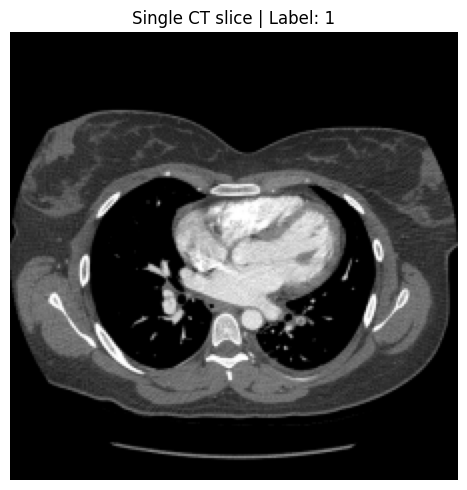

Image shape: (224, 224)
Tensor shape: (3, 224, 224)
Image range: 0.0 1.0
Preprocessing test passed.


In [ ]:
import cv2

IMAGE_SIZE = 224

PE_WINDOW_LEVEL = 100
PE_WINDOW_WIDTH = 700

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406], dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225], dtype=np.float32
)


def get_dicom_path(row):
    return (
        DATA_ROOT
        / "train"
        / str(row["StudyInstanceUID"])
        / str(row["SeriesInstanceUID"])
        / f"{row['SOPInstanceUID']}.dcm"
    )


def read_ct_hu(path):
    ds = pydicom.dcmread(str(path))

    if getattr(ds, "Modality", None) != "CT":
        raise ValueError(f"Expected CT image: {path}")

    if getattr(ds, "PhotometricInterpretation", None) != "MONOCHROME2":
        raise ValueError(f"Unexpected image interpretation: {path}")

    if not hasattr(ds, "RescaleSlope") or not hasattr(
        ds, "RescaleIntercept"
    ):
        raise ValueError(f"Missing HU conversion metadata: {path}")

    pixels = ds.pixel_array.astype(np.float32)

    if pixels.ndim != 2:
        raise ValueError(
            f"Expected a single 2D slice, found {pixels.shape}"
        )

    hu = (
        pixels * float(ds.RescaleSlope)
        + float(ds.RescaleIntercept)
    )

    if not np.isfinite(hu).all():
        raise ValueError(f"Non-finite HU values: {path}")

    return hu


def apply_pe_window(hu):
    lower = PE_WINDOW_LEVEL - PE_WINDOW_WIDTH / 2
    upper = PE_WINDOW_LEVEL + PE_WINDOW_WIDTH / 2

    image = np.clip(hu, lower, upper)
    image = (image - lower) / (upper - lower)

    return image.astype(np.float32)


def prepare_slice(path):
    image = apply_pe_window(read_ct_hu(path))

    image = cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )

    return np.ascontiguousarray(image, dtype=np.float32)


def slice_to_tensor(image):
    # تكرار الصورة نفسها إلى 3 قنوات لتوافق MobileNet
    image = np.repeat(image[..., None], 3, axis=2)

    image = (
        image - IMAGENET_MEAN
    ) / IMAGENET_STD

    image = np.ascontiguousarray(
        image.transpose(2, 0, 1),
        dtype=np.float32,
    )

    return torch.from_numpy(image)


preprocessing_config = {
    "image_size": IMAGE_SIZE,
    "window_level": PE_WINDOW_LEVEL,
    "window_width": PE_WINDOW_WIDTH,
    "channels": "Same single slice repeated three times",
    "mean": IMAGENET_MEAN.tolist(),
    "std": IMAGENET_STD.tolist(),
}

with open(
    DIRS["deployment"] / "preprocessing.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(preprocessing_config, file, indent=2)

# اختبار صورة من التدريب فقط
example_row = train_sample_df.iloc[0]
example_path = get_dicom_path(example_row)

example_image = prepare_slice(example_path)
example_tensor = slice_to_tensor(example_image)

assert example_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert torch.isfinite(example_tensor).all()

plt.figure(figsize=(5, 5))
plt.imshow(example_image, cmap="gray", vmin=0, vmax=1)
plt.title(
    f"Single CT slice | Label: {int(example_row[TARGET])}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Image shape:", example_image.shape)
print("Tensor shape:", tuple(example_tensor.shape))
print(
    "Image range:",
    float(example_image.min()),
    float(example_image.max()),
)
print("Preprocessing test passed.")

In [ ]:
def affine_slice(image, angle=0, scale=1, dx=0, dy=0):
    height, width = image.shape

    matrix = cv2.getRotationMatrix2D(
        ((width - 1) / 2, (height - 1) / 2),
        angle,
        scale,
    )

    matrix[0, 2] += dx * width
    matrix[1, 2] += dy * height

    return cv2.warpAffine(
        image,
        matrix,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )


def augment_slice(image):
    image = image.copy()

    # تحويل هندسي خفيف باحتمال 50%
    if random.random() < 0.5:
        image = affine_slice(
            image,
            angle=random.uniform(-7, 7),
            scale=random.uniform(0.95, 1.05),
            dx=random.uniform(-0.03, 0.03),
            dy=random.uniform(-0.03, 0.03),
        )

    # تعديل التباين والسطوع باحتمال 30%
    if random.random() < 0.3:
        contrast = random.uniform(0.95, 1.05)
        brightness = random.uniform(-0.02, 0.02)

        image = image * contrast + brightness

    return np.ascontiguousarray(
        np.clip(image, 0, 1),
        dtype=np.float32,
    )


augmentation_config = {
    "training_only": True,
    "affine_probability": 0.5,
    "rotation_degrees": [-7, 7],
    "scale": [0.95, 1.05],
    "horizontal_shift_fraction": [-0.03, 0.03],
    "vertical_shift_fraction": [-0.03, 0.03],
    "intensity_probability": 0.3,
    "contrast_multiplier": [0.95, 1.05],
    "brightness_offset": [-0.02, 0.02],
}

with open(
    DIRS["results"] / "augmentation_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(augmentation_config, file, indent=2)

print("Training augmentation configured.")

Training augmentation configured.


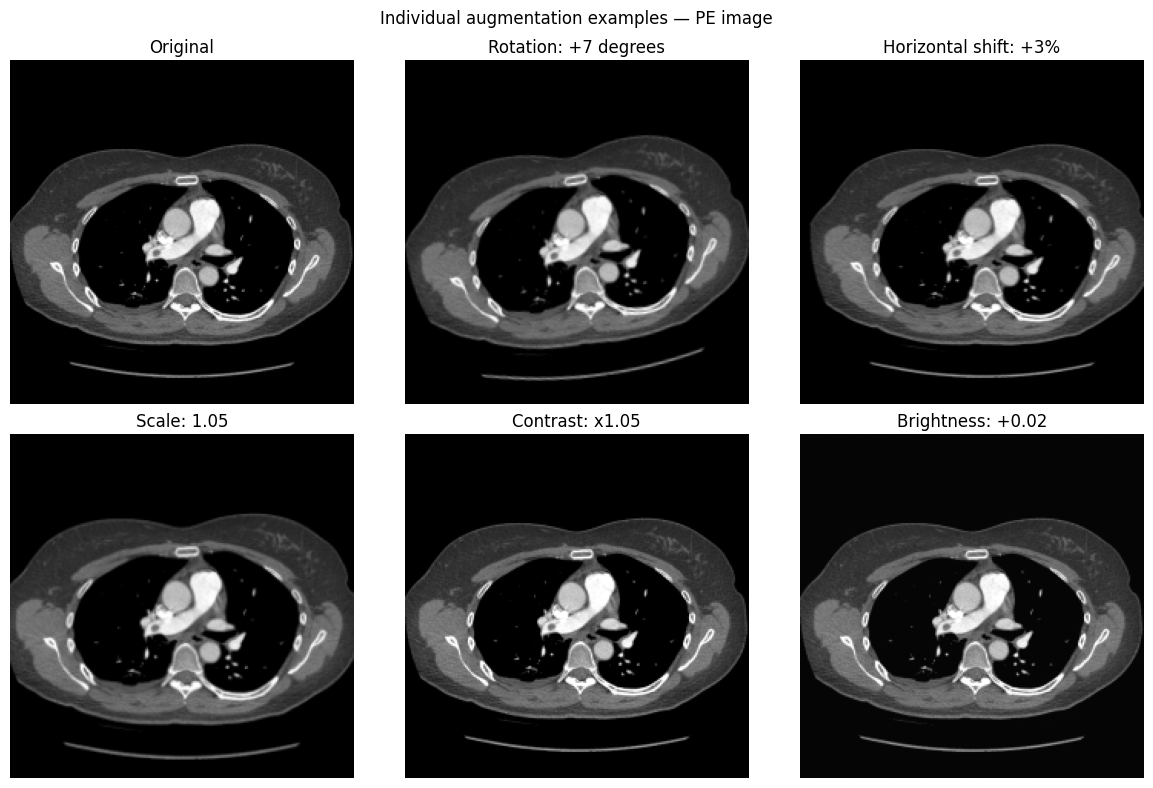

In [ ]:
preview_row = (
    train_sample_df.loc[train_sample_df[TARGET].eq(1)]
    .sample(n=1, random_state=SEED)
    .iloc[0]
)

original = prepare_slice(get_dicom_path(preview_row))

examples = [
    ("Original", original),
    ("Rotation: +7 degrees", affine_slice(original, angle=7)),
    ("Horizontal shift: +3%", affine_slice(original, dx=0.03)),
    ("Scale: 1.05", affine_slice(original, scale=1.05)),
    ("Contrast: x1.05", np.clip(original * 1.05, 0, 1)),
    ("Brightness: +0.02", np.clip(original + 0.02, 0, 1)),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for axis, (title, image) in zip(axes.flat, examples):
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Individual augmentation examples — PE image")
fig.tight_layout()

fig.savefig(
    DIRS["figures"] / "augmentation_individual_examples.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [ ]:
from torch.utils.data import Dataset, DataLoader


class PESliceDataset(Dataset):
    def __init__(self, table, augment=False):
        self.table = table[ID_COLS + [TARGET]].reset_index(
            drop=True
        ).copy()

        self.augment = augment

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        path = get_dicom_path(row)

        try:
            image = prepare_slice(path)

            if self.augment:
                image = augment_slice(image)

            tensor = slice_to_tensor(image)

        except Exception as error:
            raise RuntimeError(
                f"Failed to prepare image: {row['SOPInstanceUID']}"
            ) from error

        label = torch.tensor(
            float(row[TARGET]),
            dtype=torch.float32,
        )

        return tensor, label


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset = PESliceDataset(
    train_sample_df,
    augment=True,
)

val_dataset = PESliceDataset(
    val_df,
    augment=False,
)

test_dataset = PESliceDataset(
    test_df,
    augment=False,
)

train_generator = torch.Generator().manual_seed(SEED)

loader_settings = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": seed_worker,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=train_generator,
    **loader_settings,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_settings,
)

# نستخدمه بعد انتهاء اختيار المودل والعتبة فقط
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_settings,
)

print("Train images:", f"{len(train_dataset):,}")
print("Validation images:", f"{len(val_dataset):,}")
print("Test images:", f"{len(test_dataset):,}")
print("Train batches:", f"{len(train_loader):,}")

Train images: 198,870
Validation images: 261,527
Test images: 266,464
Train batches: 6,215


In [ ]:
# num_workers=0 لإظهار الخطأ مباشرة إذا وُجد
debug_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

x_debug, y_debug = next(iter(debug_loader))

assert x_debug.shape == (4, 3, IMAGE_SIZE, IMAGE_SIZE)
assert y_debug.shape == (4,)
assert torch.isfinite(x_debug).all()
assert torch.isfinite(y_debug).all()
assert ((y_debug == 0) | (y_debug == 1)).all()

print("Images:", tuple(x_debug.shape))
print("Labels:", y_debug.tolist())
print("Batch test passed.")

del debug_loader, x_debug, y_debug

Images: (4, 3, 224, 224)
Labels: [1.0, 0.0, 1.0, 1.0]
Batch test passed.


In [ ]:
import sys
import importlib
import traceback
import torch

print("Python:", sys.version)
print("Torch version:", getattr(torch, "__version__", "unknown"))
print("Torch path:", getattr(torch, "__file__", "unknown"))

try:
    torch_utils = importlib.import_module("torch._utils")
    print("torch._utils imported successfully")

    import torchvision
    print("Torchvision version:", torchvision.__version__)

except Exception:
    traceback.print_exc()

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Torch version: 2.11.0+cu128
Torch path: /usr/local/lib/python3.13/dist-packages/torch/__init__.py
torch._utils imported successfully
Torchvision version: 0.26.0+cu128


In [ ]:
import importlib
import torch

torch._utils = importlib.import_module("torch._utils")

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
)

check_model = mobilenet_v2(
    weights=MobileNet_V2_Weights.IMAGENET1K_V2
)

print("Pretrained weights loaded successfully.")

del check_model

Pretrained weights loaded successfully.


In [ ]:
import time
import math
import torch.nn as nn

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "فعّلي GPU من إعدادات Kaggle قبل التدريب."
    )

# تحميل الأوزان خارج قياس الوقت
speed_model = mobilenet_v2(
    weights=MobileNet_V2_Weights.IMAGENET1K_V2
)

for parameter in speed_model.features.parameters():
    parameter.requires_grad = False

speed_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(speed_model.last_channel, 1),
)

speed_model = speed_model.to(DEVICE)

speed_optimizer = torch.optim.AdamW(
    speed_model.classifier.parameters(),
    lr=1e-3,
)

# بدون وزن إضافي هنا؛ هذا اختبار سرعة فقط
speed_criterion = nn.BCEWithLogitsLoss()
speed_scaler = torch.amp.GradScaler("cuda")

speed_model.train()
speed_model.features.eval()

speed_iterator = iter(train_loader)


def speed_step():
    images, labels = next(speed_iterator)

    images = images.to(DEVICE, non_blocking=True)
    labels = labels.to(DEVICE, non_blocking=True)

    speed_optimizer.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda"):
        logits = speed_model(images).squeeze(1)
        loss = speed_criterion(logits, labels)

    speed_scaler.scale(loss).backward()
    speed_scaler.step(speed_optimizer)
    speed_scaler.update()


# تهيئة GPU والـDataLoader قبل القياس
for _ in range(3):
    speed_step()

torch.cuda.synchronize()

MEASURE_BATCHES = 30
start = time.perf_counter()

for _ in range(MEASURE_BATCHES):
    speed_step()

torch.cuda.synchronize()

elapsed = time.perf_counter() - start
seconds_per_batch = elapsed / MEASURE_BATCHES

train_minutes = (
    seconds_per_batch * len(train_loader) / 60
)

print(f"Seconds per training batch: {seconds_per_batch:.3f}")
print(f"Estimated head-training epoch: {train_minutes:.1f} minutes")
print("Validation time is additional.")
print("Fine-tuning may be slower.")

speed_result = {
    "measured_batches": MEASURE_BATCHES,
    "batch_size": BATCH_SIZE,
    "seconds_per_batch": seconds_per_batch,
    "estimated_head_train_minutes": train_minutes,
    "gpu": torch.cuda.get_device_name(0),
}

with open(
    DIRS["results"] / "training_speed.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(speed_result, file, indent=2)

del speed_iterator
del speed_model, speed_optimizer, speed_scaler
torch.cuda.empty_cache()

Seconds per training batch: 0.507
Estimated head-training epoch: 52.6 minutes
Validation time is additional.
Fine-tuning may be slower.


In [ ]:
from sklearn.model_selection import train_test_split

# حجم التجربة السريعة
FAST_TRAIN_SIZE = 20_000
FAST_VAL_SIZE = 5_000

# إعدادات التدريب
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3
MIN_DELTA = 0.001
MONITOR_METRIC = "val_ap"

# عينة من الترين بعد تقليل السلبيات:
# تقريبًا ثلث مصاب وثلثين غير مصاب
train_fast_df, _ = train_test_split(
    train_sample_df,
    train_size=FAST_TRAIN_SIZE,
    stratify=train_sample_df[TARGET],
    random_state=SEED,
)

# عينة فاليديشن بتوزيع الفئتين الطبيعي
val_fast_df, _ = train_test_split(
    val_df,
    train_size=FAST_VAL_SIZE,
    stratify=val_df[TARGET],
    random_state=SEED,
)

train_fast_df = train_fast_df.reset_index(drop=True)
val_fast_df = val_fast_df.reset_index(drop=True)

# التأكد أن العينات من أقسامها الأصلية
assert set(train_fast_df["SOPInstanceUID"]).issubset(
    set(train_df["SOPInstanceUID"])
)

assert set(val_fast_df["SOPInstanceUID"]).issubset(
    set(val_df["SOPInstanceUID"])
)

# فحص عدم تداخل الدراسات والسلاسل والصور
for column in ID_COLS:
    train_ids = set(train_fast_df[column])
    val_ids = set(val_fast_df[column])
    test_ids = set(test_df[column])

    assert train_ids.isdisjoint(val_ids), column
    assert train_ids.isdisjoint(test_ids), column
    assert val_ids.isdisjoint(test_ids), column

# Dataset: الأوقمنتيشن للترين فقط
train_dataset = PESliceDataset(
    train_fast_df,
    augment=True,
)

val_monitor_dataset = PESliceDataset(
    val_fast_df,
    augment=False,
)

train_generator = torch.Generator().manual_seed(SEED)

# استبدال Loader التدريب الكبير بالعينة الصغيرة
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=train_generator,
    **loader_settings,
)

val_monitor_loader = DataLoader(
    val_monitor_dataset,
    shuffle=False,
    **loader_settings,
)

# حفظ العينات المستخدمة في التجربة
train_fast_df.to_csv(
    DIRS["splits"] / "train_fast_20000.csv",
    index=False,
)

val_fast_df.to_csv(
    DIRS["splits"] / "validation_fast_5000.csv",
    index=False,
)

fast_config = {
    "train_images": len(train_fast_df),
    "validation_monitor_images": len(val_fast_df),
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "min_delta": MIN_DELTA,
    "monitor_metric": MONITOR_METRIC,
    "seed": SEED,
}

with open(
    DIRS["results"] / "fast_training_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(fast_config, file, indent=2)

display(pd.DataFrame([
    {
        "split": name,
        "images": len(table),
        "negative": int(table[TARGET].eq(0).sum()),
        "positive": int(table[TARGET].eq(1).sum()),
    }
    for name, table in [
        ("Fast train", train_fast_df),
        ("Fast validation", val_fast_df),
    ]
]))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_monitor_loader))
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Ready to create the model. Training has not started.")

,split,images,negative,positive
0,Fast train,20000,13333,6667
1,Fast validation,5000,4726,274


Train batches: 625
Validation batches: 157
Maximum epochs: 20
Early stopping patience: 3
Ready to create the model. Training has not started.


In [ ]:
import torch.nn as nn

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights,
)

# مسارات مستقلة للتجربة الصغيرة
HEAD_BEST_PATH = DIRS["models"] / "mobilenetv2_fast_head_best.pth"
HEAD_LAST_PATH = DIRS["models"] / "mobilenetv2_fast_head_last.pth"

# عند وجود checkpoint، نسترجعه في حلقة التدريب القادمة
weights = (
    None
    if HEAD_LAST_PATH.exists()
    else MobileNet_V2_Weights.IMAGENET1K_V2
)

model = mobilenet_v2(weights=weights)

# تجميد مستخرج الخصائص
for parameter in model.features.parameters():
    parameter.requires_grad = False

# مخرج واحد للتصنيف الثنائي
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(model.last_channel, 1),
)

model = model.to(DEVICE)

# العينة فيها مصاب بنسبة 33% تقريبًا،
# لذلك نبدأ بدون وزن إضافي للفئة المصابة
criterion = nn.BCEWithLogitsLoss()

LEARNING_RATE = 1e-3

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

USE_AMP = DEVICE.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

# اختبار شكل المخرج
model.eval()

with torch.no_grad():
    dummy_input = torch.zeros(
        2, 3, IMAGE_SIZE, IMAGE_SIZE,
        device=DEVICE,
    )

    dummy_output = model(dummy_input)

assert dummy_output.shape == (2, 1)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model: MobileNetV2")
print("Output shape:", tuple(dummy_output.shape))
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Model ready. Training has not started.")

del dummy_input, dummy_output

Model: MobileNetV2
Output shape: (2, 1)
Total parameters: 2,225,153
Trainable parameters: 1,281
Maximum epochs: 20
Early stopping patience: 3
Model ready. Training has not started.


In [ ]:
import time
import hashlib

from tqdm.auto import tqdm

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


def calculate_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float64)

    if not np.isfinite(probabilities).all():
        raise ValueError("Non-finite predictions.")

    predictions = (probabilities >= threshold).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if tn + fp else 0.0
    recall = recall_score(labels, predictions, zero_division=0)

    return {
        "ap": float(average_precision_score(labels, probabilities)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "accuracy": float(accuracy_score(labels, predictions)),
        "balanced_accuracy": float((recall + specificity) / 2),
        "precision": float(
            precision_score(labels, predictions, zero_division=0)
        ),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def train_one_epoch():
    model.train()

    # إبقاء BatchNorm في المستخرج المجمد دون تحديث
    model.features.eval()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(train_loader, desc="Training")

    for images, labels in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP,
        ):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.4f}"
        )

    return total_loss / total_images


@torch.no_grad()
def evaluate_model(loader):
    model.eval()

    total_loss = 0.0
    total_images = 0
    all_labels = []
    all_probabilities = []

    for images, labels in tqdm(loader, desc="Validation"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP,
        ):
            logits = model(images).squeeze(1)

        # حساب الخسارة والاحتمالات بدقة float32
        logits = logits.float()
        loss = criterion(logits, labels)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite validation loss.")

        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_images += batch_size

        all_labels.append(labels.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    labels = np.concatenate(all_labels)
    probabilities = np.concatenate(all_probabilities)

    metrics = calculate_metrics(labels, probabilities)
    metrics["loss"] = total_loss / total_images

    return metrics, labels, probabilities


def atomic_torch_save(data, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    torch.save(data, temporary_path)
    temporary_path.replace(path)


def table_fingerprint(table):
    # التحقق من معرّفات الصور وترتيبها وتصنيفاتها عند الاستكمال
    values = pd.util.hash_pandas_object(
        table[ID_COLS + [TARGET]],
        index=False,
    ).to_numpy()

    return hashlib.sha256(values.tobytes()).hexdigest()


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


In [ ]:
run_config = {
    "architecture": "mobilenet_v2",
    "stage": "frozen_backbone_head_training",
    "train_fingerprint": table_fingerprint(train_fast_df),
    "validation_fingerprint": table_fingerprint(val_fast_df),
    "preprocessing": preprocessing_config,
    "augmentation": augmentation_config,
    "learning_rate": LEARNING_RATE,
    "weight_decay": 1e-4,
    "batch_size": BATCH_SIZE,
    "loss": "BCEWithLogitsLoss_without_class_weight",
    "patience": EARLY_STOPPING_PATIENCE,
    "min_delta": MIN_DELTA,
    "seed": SEED,
}

start_epoch = 0
best_ap = -float("inf")
early_stop_reference = -float("inf")
bad_epochs = 0
history = []

# الاستكمال من آخر إيبوك مكتمل
if HEAD_LAST_PATH.exists():
    checkpoint = torch.load(
        HEAD_LAST_PATH,
        map_location=DEVICE,
        weights_only=True,
    )

    if checkpoint["config"] != run_config:
        raise ValueError(
            "Checkpoint settings or data differ from this run. "
            "Use new checkpoint paths for a different experiment."
        )

    if not HEAD_BEST_PATH.exists():
        raise FileNotFoundError("Best checkpoint is missing.")

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scaler.load_state_dict(checkpoint["scaler"])

    start_epoch = checkpoint["epoch"] + 1
    best_ap = checkpoint["best_ap"]
    early_stop_reference = checkpoint["early_stop_reference"]
    bad_epochs = checkpoint["bad_epochs"]
    history = checkpoint["history"]

    print(f"Resuming after epoch {start_epoch}")
    print(f"Best validation AP: {best_ap:.4f}")

with open(
    DIRS["results"] / "head_run_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(run_config, file, indent=2)

for epoch in range(start_epoch, MAX_EPOCHS):
    if bad_epochs >= EARLY_STOPPING_PATIENCE:
        print("Early stopping already reached.")
        break

    # ترتيب تدريب ثابت لكل إيبوك
    random.seed(SEED + epoch)
    np.random.seed(SEED + epoch)
    torch.manual_seed(SEED + epoch)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(SEED + epoch)

    train_generator.manual_seed(SEED + epoch)

    print(f"\nEpoch {epoch + 1}/{MAX_EPOCHS}")
    epoch_start = time.perf_counter()

    train_loss = train_one_epoch()

    val_metrics, val_labels, val_probabilities = evaluate_model(
        val_monitor_loader
    )

    current_ap = val_metrics["ap"]

    # حفظ أفضل مودل لأي تحسن في AP
    if current_ap > best_ap:
        best_ap = current_ap

        atomic_torch_save(
            {
                "epoch": epoch,
                "model": model.state_dict(),
                "val_metrics": val_metrics,
                "config": run_config,
            },
            HEAD_BEST_PATH,
        )

        np.savez_compressed(
            DIRS["results"] / "head_best_validation_predictions.npz",
            image_ids=val_fast_df["SOPInstanceUID"].to_numpy(
                dtype=str
            ),
            labels=val_labels,
            probabilities=val_probabilities,
        )

        print("Best model saved.")

    # التوقف بعد 3 إيبوكس دون تحسن معتبر
    if current_ap > early_stop_reference + MIN_DELTA:
        early_stop_reference = current_ap
        bad_epochs = 0
    else:
        bad_epochs += 1

    row = {
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        **{
            f"val_{key}": value
            for key, value in val_metrics.items()
        },
        "minutes": (time.perf_counter() - epoch_start) / 60,
        "bad_epochs": bad_epochs,
    }

    history.append(row)

    # حفظ آخر إيبوك مكتمل للاستكمال
    atomic_torch_save(
        {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict(),
            "best_ap": best_ap,
            "early_stop_reference": early_stop_reference,
            "bad_epochs": bad_epochs,
            "history": history,
            "config": run_config,
        },
        HEAD_LAST_PATH,
    )

    pd.DataFrame(history).to_csv(
        DIRS["results"] / "head_training_history.csv",
        index=False,
    )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"AP: {current_ap:.4f} | "
        f"ROC-AUC: {val_metrics['roc_auc']:.4f}"
    )

    print(
        f"Precision: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"F1: {val_metrics['f1']:.4f} | "
        f"Time: {row['minutes']:.1f} min"
    )

    print(
        f"Early stopping counter: "
        f"{bad_epochs}/{EARLY_STOPPING_PATIENCE}"
    )

    if bad_epochs >= EARLY_STOPPING_PATIENCE:
        print("Early stopping activated.")
        break

# استرجاع أفضل مودل بدل أوزان آخر إيبوك
best_checkpoint = torch.load(
    HEAD_BEST_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(best_checkpoint["model"])
model.eval()

print(
    "\nBest epoch:",
    best_checkpoint["epoch"] + 1,
)

display(
    pd.DataFrame(
        [best_checkpoint["val_metrics"]]
    )
)

print("Best model:", HEAD_BEST_PATH)
print("Resume checkpoint:", HEAD_LAST_PATH)


Epoch 1/20


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Best model saved.
Train loss: 0.4710 | Val loss: 0.3359 | AP: 0.1670 | ROC-AUC: 0.8280
Precision: 0.1575 | Recall: 0.5876 | F1: 0.2485 | Time: 5.6 min
Early stopping counter: 0/3

Epoch 2/20


Training:   0%|          | 0/625 [00:00<?, ?it/s]

...

Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train loss: 0.4375 | Val loss: 0.3356 | AP: 0.1837 | ROC-AUC: 0.8341
Precision: 0.1578 | Recall: 0.6277 | F1: 0.2522 | Time: 1.6 min
Early stopping counter: 3/3
Early stopping activated.

Best epoch: 3


,ap,roc_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp,loss
0,0.18717,0.835398,0.7802,0.720421,0.15131,0.653285,0.787558,0.24571,3722,1004,95,179,0.350974


Best model: /kaggle/working/PE_Single_Image_Binary_v2/models/mobilenetv2_fast_head_best.pth
Resume checkpoint: /kaggle/working/PE_Single_Image_Binary_v2/models/mobilenetv2_fast_head_last.pth


In [ ]:
FT_BEST_PATH = DIRS["models"] / "mobilenetv2_fast_ft_best.pth"
FT_LAST_PATH = DIRS["models"] / "mobilenetv2_fast_ft_last.pth"

BACKBONE_LR = 1e-5
HEAD_LR = 1e-4

head_checkpoint = torch.load(
    HEAD_BEST_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(head_checkpoint["model"])

for parameter in model.features.parameters():
    parameter.requires_grad = False

for parameter in model.features[-4:].parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.features[-4:].parameters(),
            "lr": BACKBONE_LR,
        },
        {
            "params": model.classifier.parameters(),
            "lr": HEAD_LR,
        },
    ],
    weight_decay=1e-4,
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

ft_config = {
    **run_config,
    "stage": "last_four_blocks_fine_tuning",
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "head_checkpoint_sha256": hashlib.sha256(
        HEAD_BEST_PATH.read_bytes()
    ).hexdigest(),
}

ft_history = []
ft_start_epoch = 0
ft_best_ap = head_checkpoint["val_metrics"]["ap"]
ft_reference = ft_best_ap
ft_bad_epochs = 0

if FT_LAST_PATH.exists():
    checkpoint = torch.load(
        FT_LAST_PATH,
        map_location=DEVICE,
        weights_only=True,
    )

    if checkpoint["config"] != ft_config:
        raise ValueError("Fine-tuning checkpoint configuration differs.")

    if not FT_BEST_PATH.exists():
        raise FileNotFoundError("Best fine-tuning checkpoint missing.")

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scaler.load_state_dict(checkpoint["scaler"])

    ft_start_epoch = checkpoint["epoch"] + 1
    ft_best_ap = checkpoint["best_ap"]
    ft_reference = checkpoint["reference"]
    ft_bad_epochs = checkpoint["bad_epochs"]
    ft_history = checkpoint["history"]

else:
    # حفظ الرأس كخط أساس قبل أي تعديل
    atomic_torch_save(
        {
            "epoch": -1,
            "selected_stage": "head",
            "model": model.state_dict(),
            "val_metrics": head_checkpoint["val_metrics"],
            "config": ft_config,
        },
        FT_BEST_PATH,
    )

for epoch in range(ft_start_epoch, MAX_EPOCHS):
    if ft_bad_epochs >= EARLY_STOPPING_PATIENCE:
        break

    random.seed(SEED + 1000 + epoch)
    np.random.seed(SEED + 1000 + epoch)
    torch.manual_seed(SEED + 1000 + epoch)
    train_generator.manual_seed(SEED + 1000 + epoch)

    print(f"\nFine-tuning epoch {epoch + 1}/{MAX_EPOCHS}")
    started = time.perf_counter()

    # الدالة السابقة تُبقي BatchNorm ثابتًا،
    # مع تحديث أوزان الأجزاء المفتوحة
    train_loss = train_one_epoch()

    metrics, labels, probabilities = evaluate_model(
        val_monitor_loader
    )

    if metrics["ap"] > ft_best_ap:
        ft_best_ap = metrics["ap"]

        atomic_torch_save(
            {
                "epoch": epoch,
                "selected_stage": "fine_tuning",
                "model": model.state_dict(),
                "val_metrics": metrics,
                "config": ft_config,
            },
            FT_BEST_PATH,
        )

        print("Improved model saved.")

    if metrics["ap"] > ft_reference + MIN_DELTA:
        ft_reference = metrics["ap"]
        ft_bad_epochs = 0
    else:
        ft_bad_epochs += 1

    ft_history.append({
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        **{f"val_{key}": value for key, value in metrics.items()},
        "minutes": (time.perf_counter() - started) / 60,
        "bad_epochs": ft_bad_epochs,
    })

    atomic_torch_save(
        {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict(),
            "best_ap": ft_best_ap,
            "reference": ft_reference,
            "bad_epochs": ft_bad_epochs,
            "history": ft_history,
            "config": ft_config,
        },
        FT_LAST_PATH,
    )

    pd.DataFrame(ft_history).to_csv(
        DIRS["results"] / "fine_tuning_history.csv",
        index=False,
    )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {metrics['loss']:.4f} | "
        f"AP: {metrics['ap']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f}"
    )
    print(
        f"Early stopping: "
        f"{ft_bad_epochs}/{EARLY_STOPPING_PATIENCE}"
    )

selected_checkpoint = torch.load(
    FT_BEST_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(selected_checkpoint["model"])
model.eval()

comparison = pd.DataFrame([
    {"model": "Head", **head_checkpoint["val_metrics"]},
    {
        "model": f"Selected: {selected_checkpoint['selected_stage']}",
        **selected_checkpoint["val_metrics"],
    },
])

display(comparison)

comparison.to_csv(
    DIRS["results"] / "head_vs_fine_tuning.csv",
    index=False,
)

print("Selected stage:", selected_checkpoint["selected_stage"])


Fine-tuning epoch 1/20


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train loss: 0.4384 | Val loss: 0.4073 | AP: 0.1846 | ROC-AUC: 0.8356
Early stopping: 1/3

Fine-tuning epoch 2/20


Training:   0%|          | 0/625 [00:00<?, ?it/s]

...

Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train loss: 0.3743 | Val loss: 0.2980 | AP: 0.2046 | ROC-AUC: 0.8453
Early stopping: 3/3


,model,ap,roc_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp,loss
0,Head,0.187170,0.835398,0.7802,0.720421,0.15131,0.653285,0.787558,0.245710,3722,1004,95,179,0.350974
1,Selected: fine_tuning,0.216743,0.847115,0.8280,0.728517,0.18290,0.616788,0.840245,0.282137,3971,755,105,169,0.302940


Selected stage: fine_tuning


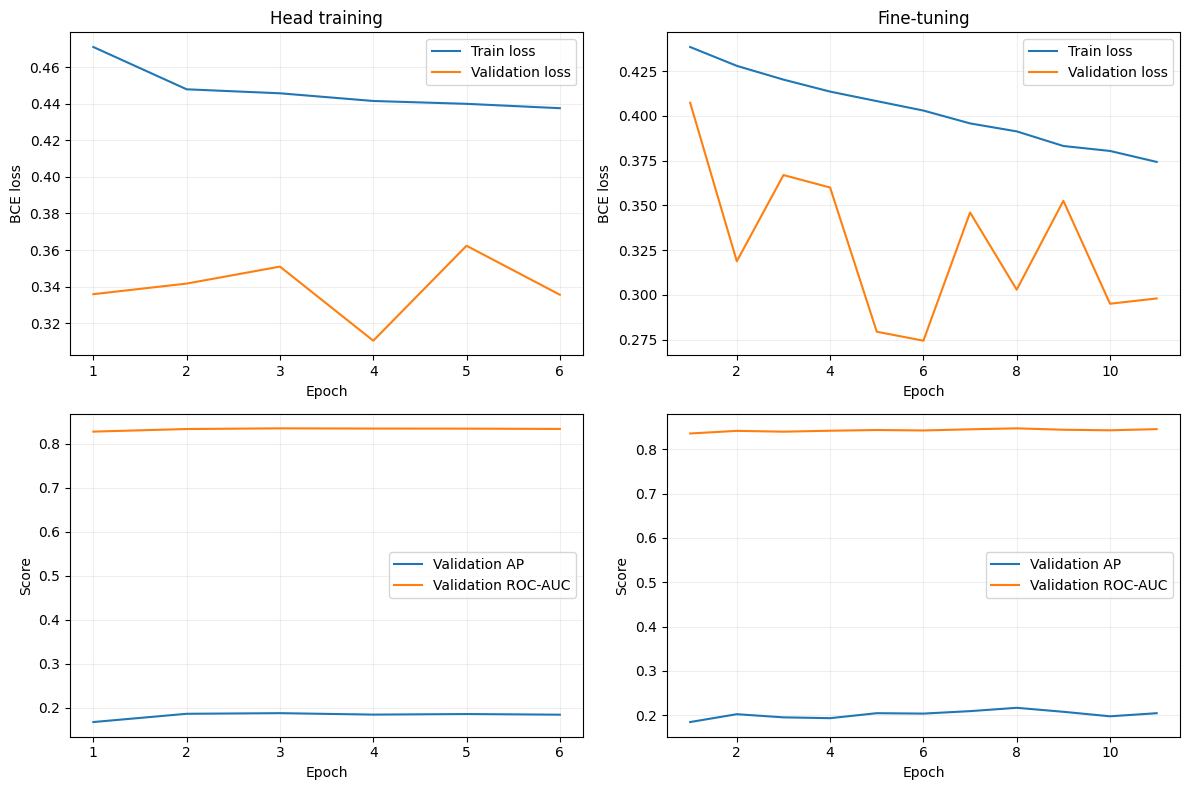

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for column, (title, records) in enumerate([
    ("Head training", history),
    ("Fine-tuning", ft_history),
]):
    table = pd.DataFrame(records)

    if table.empty:
        axes[0, column].set_visible(False)
        axes[1, column].set_visible(False)
        continue

    axes[0, column].plot(
        table["epoch"], table["train_loss"], label="Train loss"
    )
    axes[0, column].plot(
        table["epoch"], table["val_loss"], label="Validation loss"
    )
    axes[0, column].set_title(title)
    axes[0, column].set_xlabel("Epoch")
    axes[0, column].set_ylabel("BCE loss")
    axes[0, column].legend()

    axes[1, column].plot(
        table["epoch"], table["val_ap"], label="Validation AP"
    )
    axes[1, column].plot(
        table["epoch"], table["val_roc_auc"],
        label="Validation ROC-AUC"
    )
    axes[1, column].set_xlabel("Epoch")
    axes[1, column].set_ylabel("Score")
    axes[1, column].legend()

for axis in axes.flat:
    axis.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(
    DIRS["figures"] / "training_curves.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

In [ ]:
from sklearn.metrics import precision_recall_curve

model.load_state_dict(selected_checkpoint["model"])

full_val_metrics, full_val_labels, full_val_probs = evaluate_model(
    val_loader
)

assert len(full_val_labels) == len(val_df)

precision, recall, thresholds = precision_recall_curve(
    full_val_labels,
    full_val_probs,
)

f1_values = (
    2 * precision[:-1] * recall[:-1]
    / np.maximum(precision[:-1] + recall[:-1], 1e-12)
)

best_index = int(np.argmax(f1_values))
SELECTED_THRESHOLD = float(thresholds[best_index])

val_tuned_metrics = calculate_metrics(
    full_val_labels,
    full_val_probs,
    threshold=SELECTED_THRESHOLD,
)

threshold_comparison = pd.DataFrame([
    {
        "threshold": 0.5,
        **calculate_metrics(full_val_labels, full_val_probs, 0.5),
    },
    {
        "threshold": SELECTED_THRESHOLD,
        **val_tuned_metrics,
    },
])

display(threshold_comparison)

threshold_comparison.to_csv(
    DIRS["results"] / "validation_threshold_comparison.csv",
    index=False,
)

np.savez_compressed(
    DIRS["results"] / "full_validation_predictions.npz",
    image_ids=val_df["SOPInstanceUID"].to_numpy(dtype=str),
    labels=full_val_labels,
    probabilities=full_val_probs,
)

with open(
    DIRS["deployment"] / "threshold.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump({
        "threshold": SELECTED_THRESHOLD,
        "selection": "Maximum F1 on full validation",
    }, file, indent=2)

print("Frozen threshold:", SELECTED_THRESHOLD)

Validation:   0%|          | 0/8173 [00:00<?, ?it/s]

,threshold,ap,roc_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp
0,0.500000,0.22277,0.848686,0.821219,0.726358,0.176911,0.619825,0.832890,0.275258,205892,41310,5446,8879
1,0.603348,0.22277,0.848686,0.881832,0.665826,0.211218,0.423246,0.908407,0.281803,224560,22642,8262,6063


Frozen threshold: 0.6033477187156677


Validation:   0%|          | 0/8327 [00:00<?, ?it/s]

,ap,roc_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,tn,fp,fn,tp,log_loss,brier_score,threshold,images
0,0.244176,0.844593,0.880464,0.670203,0.23157,0.431397,0.909008,0.301369,227742,22797,9055,6870,0.31393,0.107714,0.603348,266464


,images
outcome,
TN,227742
FP,22797
FN,9055
TP,6870


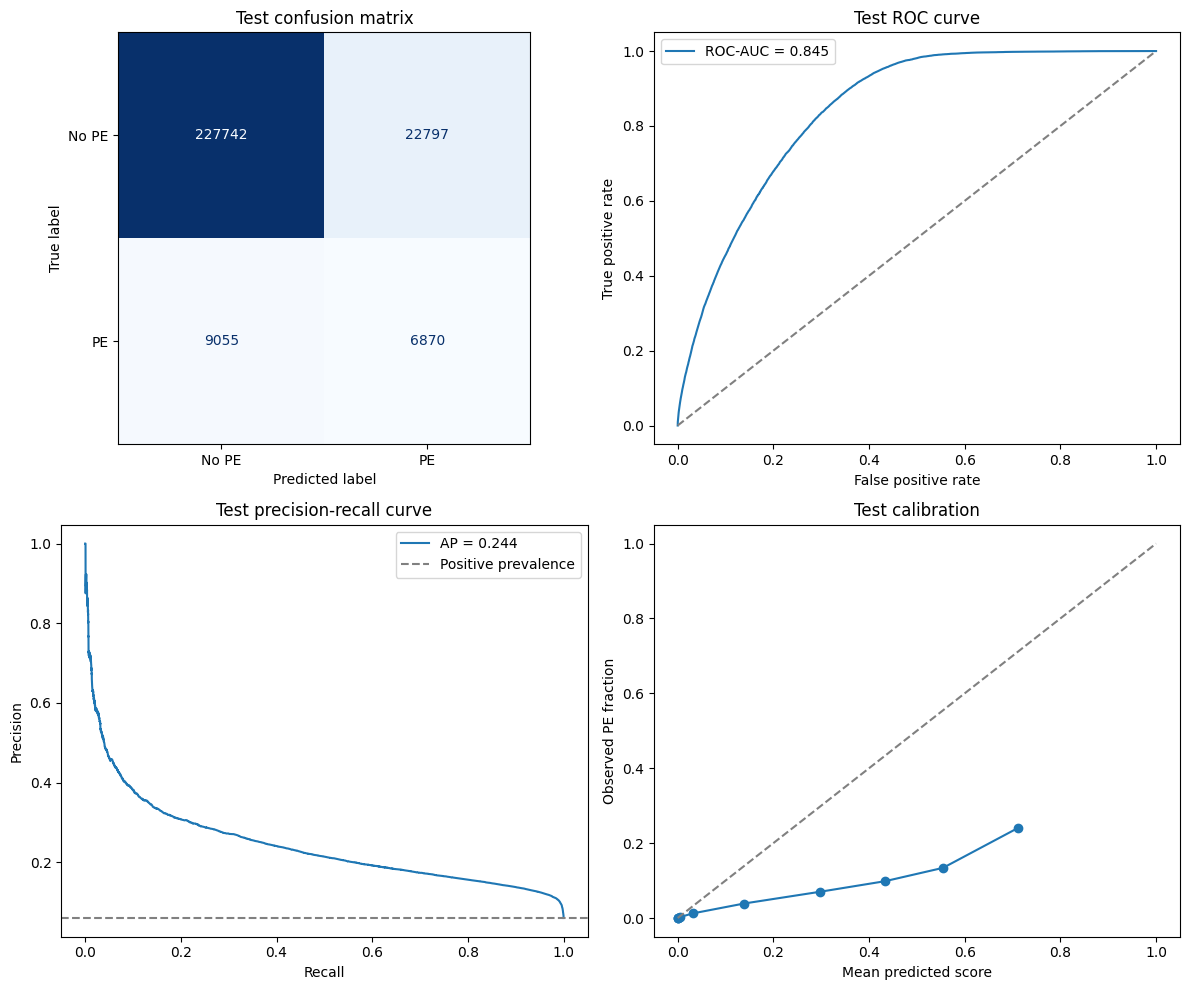

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    log_loss,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

test_default_metrics, test_labels, test_probs = evaluate_model(
    test_loader
)

assert len(test_labels) == len(test_df)

test_predictions = (
    test_probs >= SELECTED_THRESHOLD
).astype(np.int64)

test_metrics = {
    **calculate_metrics(
        test_labels,
        test_probs,
        SELECTED_THRESHOLD,
    ),
    "log_loss": float(log_loss(test_labels, test_probs, labels=[0, 1])),
    "brier_score": float(brier_score_loss(test_labels, test_probs)),
    "threshold": SELECTED_THRESHOLD,
    "images": len(test_labels),
}

display(pd.DataFrame([test_metrics]))

pd.DataFrame([test_metrics]).to_csv(
    DIRS["results"] / "final_test_metrics.csv",
    index=False,
)

test_results = test_df.copy()
test_results["probability"] = test_probs
test_results["prediction"] = test_predictions

test_results["outcome"] = np.select(
    [
        (test_labels == 1) & (test_predictions == 1),
        (test_labels == 0) & (test_predictions == 0),
        (test_labels == 0) & (test_predictions == 1),
    ],
    ["TP", "TN", "FP"],
    default="FN",
)

test_results.to_csv(
    DIRS["results"] / "test_predictions.csv",
    index=False,
)

display(
    test_results["outcome"].value_counts().rename("images").to_frame()
)

# أعلى الأخطاء ثقةً لفحصها بصريًا
false_positives = test_results.loc[
    test_results["outcome"].eq("FP")
].sort_values("probability", ascending=False)

false_negatives = test_results.loc[
    test_results["outcome"].eq("FN")
].sort_values("probability")

pd.concat([
    false_positives.head(50),
    false_negatives.head(50),
]).to_csv(
    DIRS["results"] / "errors_for_review.csv",
    index=False,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    labels=[0, 1],
    display_labels=["No PE", "PE"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Test confusion matrix")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0, 1].plot(
    fpr, tpr,
    label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}"
)
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 1].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Test ROC curve",
)
axes[0, 1].legend()

pr_precision, pr_recall, _ = precision_recall_curve(
    test_labels, test_probs
)
axes[1, 0].plot(
    pr_recall, pr_precision,
    label=f"AP = {test_metrics['ap']:.3f}"
)
axes[1, 0].axhline(
    test_labels.mean(),
    linestyle="--",
    color="gray",
    label="Positive prevalence",
)
axes[1, 0].set(
    xlabel="Recall", ylabel="Precision",
    title="Test precision-recall curve"
)
axes[1, 0].legend()

observed, predicted = calibration_curve(
    test_labels,
    test_probs,
    n_bins=10,
    strategy="quantile",
)
axes[1, 1].plot(predicted, observed, marker="o")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[1, 1].set(
    xlabel="Mean predicted score",
    ylabel="Observed PE fraction",
    title="Test calibration",
)

fig.tight_layout()
fig.savefig(
    DIRS["figures"] / "final_test_analysis.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

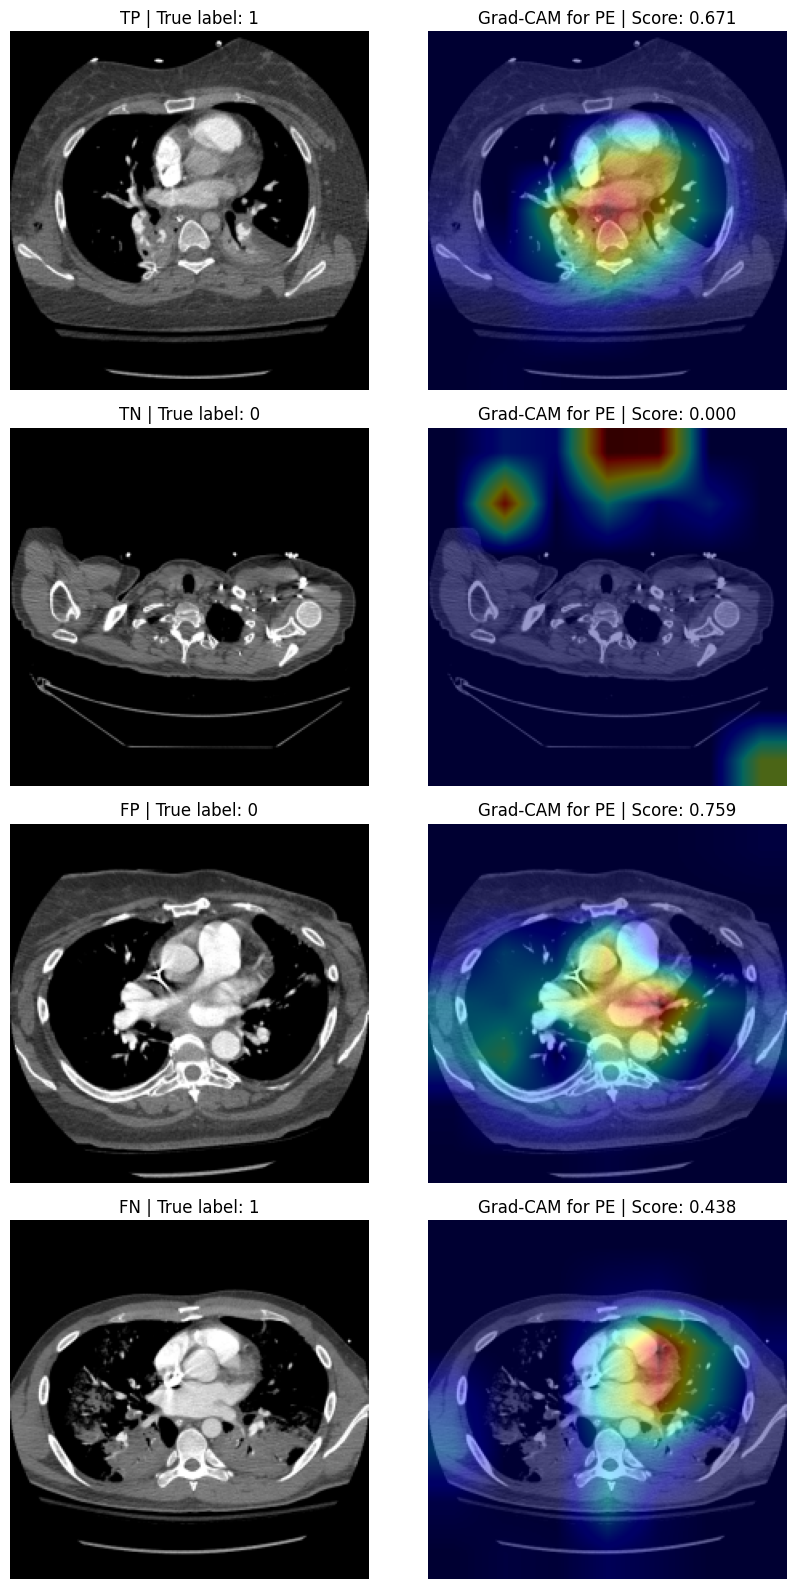

In [ ]:
def make_gradcam(row):
    image = prepare_slice(get_dicom_path(row))

    tensor = (
        slice_to_tensor(image)
        .unsqueeze(0)
        .to(DEVICE)
        .requires_grad_(True)
    )

    captured = {}

    def capture_activation(module, inputs, output):
        captured["activation"] = output
        output.retain_grad()

    hook = model.features[-1].register_forward_hook(
        capture_activation
    )

    try:
        model.eval()
        model.zero_grad(set_to_none=True)

        # بدون AMP لتحسين الاستقرار العددي للخريطة
        logit = model(tensor).squeeze()
        probability = float(torch.sigmoid(logit).detach().cpu())

        logit.backward()

        activation = captured["activation"].detach()
        gradients = captured["activation"].grad.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = torch.relu(
            (weights * activation).sum(dim=1)
        )[0].cpu().numpy()

        cam = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))

        if cam.max() > 0:
            cam = cam / cam.max()

        return image, cam, probability

    finally:
        hook.remove()
        model.zero_grad(set_to_none=True)


# مثال واحد من كل نتيجة إن وُجد
cam_rows = []

for outcome in ["TP", "TN", "FP", "FN"]:
    group = test_results.loc[
        test_results["outcome"].eq(outcome)
    ]

    if not group.empty:
        cam_rows.append(
            group.sample(n=1, random_state=SEED).iloc[0]
        )

fig, axes = plt.subplots(
    len(cam_rows), 2,
    figsize=(9, 4 * len(cam_rows)),
    squeeze=False,
)

for index, row in enumerate(cam_rows):
    image, cam, probability = make_gradcam(row)

    axes[index, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[index, 0].set_title(
        f"{row['outcome']} | True label: {int(row[TARGET])}"
    )

    axes[index, 1].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[index, 1].imshow(
        cam, cmap="jet", alpha=0.4, vmin=0, vmax=1
    )
    axes[index, 1].set_title(
        f"Grad-CAM for PE | Score: {probability:.3f}"
    )

    for axis in axes[index]:
        axis.axis("off")

    np.save(
        DIRS["gradcam"] / f"{row['SOPInstanceUID']}_cam.npy",
        cam,
    )

fig.tight_layout()
fig.savefig(
    DIRS["gradcam"] / "gradcam_examples.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

,precision,recall,f1-score,support
No PE,0.961760,0.909008,0.934641,250539.000000
PE,0.231570,0.431397,0.301369,15925.000000
accuracy,0.880464,0.880464,0.880464,0.880464
macro avg,0.596665,0.670203,0.618005,266464.000000
weighted avg,0.918121,0.880464,0.896794,266464.000000


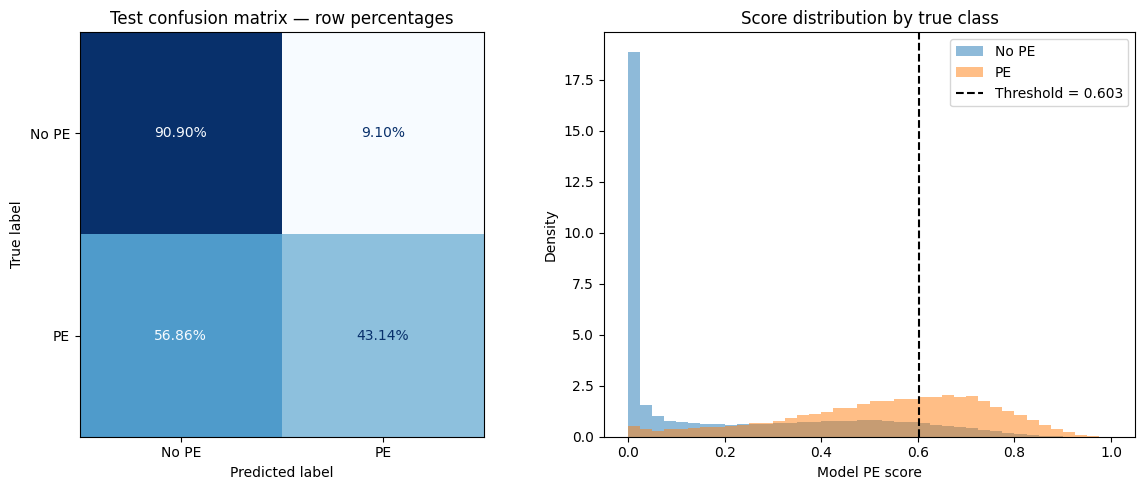

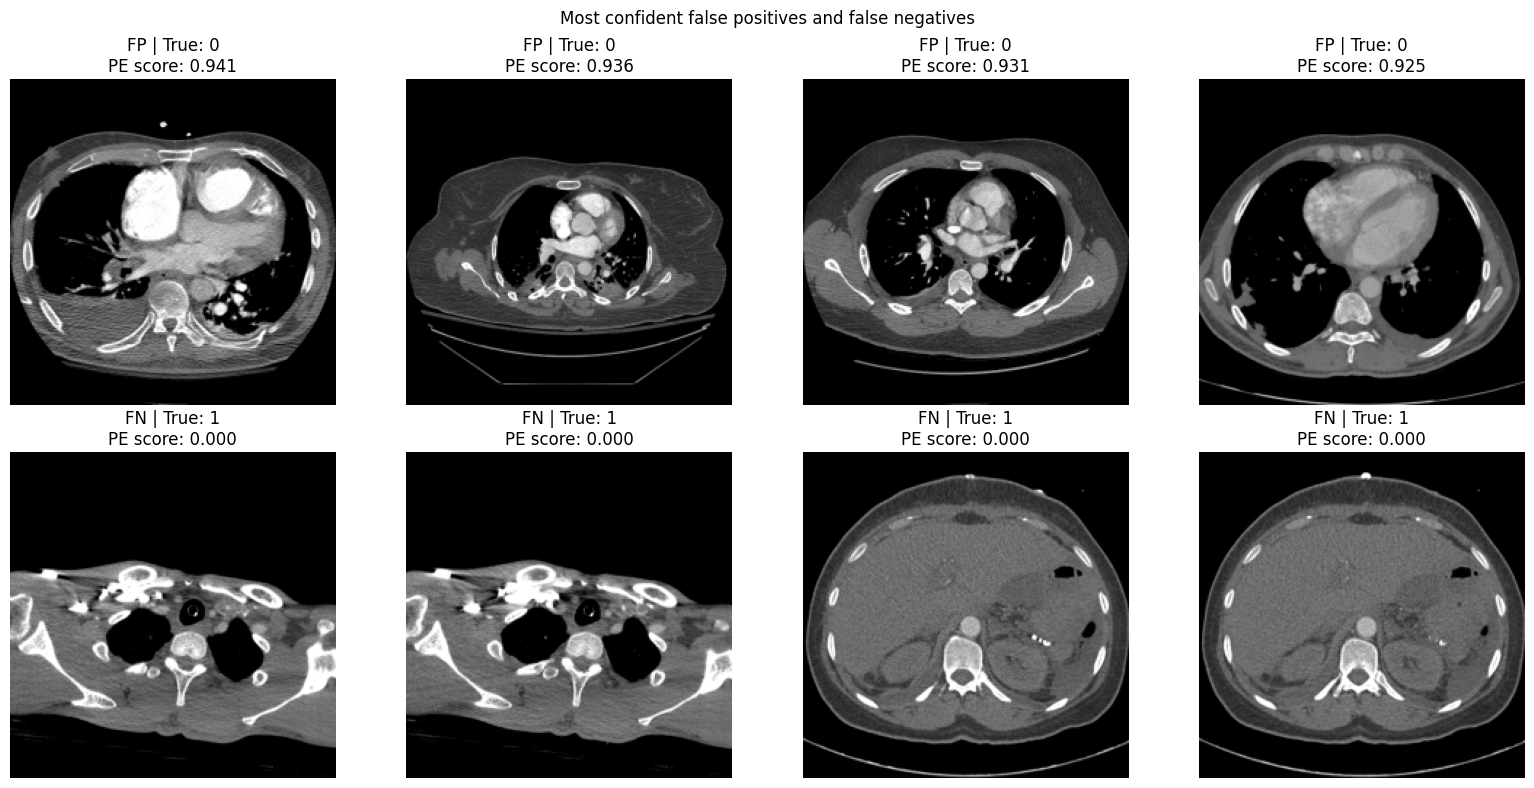

Additional analysis saved.


In [ ]:
from sklearn.metrics import classification_report

# 1) تقرير الأداء لكل فئة
report = classification_report(
    test_labels,
    test_predictions,
    labels=[0, 1],
    target_names=["No PE", "PE"],
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(
    DIRS["results"] / "test_classification_report.csv"
)

# 2) مصفوفة بالنسب + توزيع درجات المودل
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    labels=[0, 1],
    display_labels=["No PE", "PE"],
    normalize="true",
    values_format=".2%",
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)

axes[0].set_title("Test confusion matrix — row percentages")

for label, name in [(0, "No PE"), (1, "PE")]:
    axes[1].hist(
        test_probs[test_labels == label],
        bins=np.linspace(0, 1, 41),
        density=True,
        alpha=0.5,
        label=name,
    )

axes[1].axvline(
    SELECTED_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Threshold = {SELECTED_THRESHOLD:.3f}",
)

axes[1].set(
    xlabel="Model PE score",
    ylabel="Density",
    title="Score distribution by true class",
)

axes[1].legend()
fig.tight_layout()

fig.savefig(
    DIRS["figures"] / "normalized_cm_and_score_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# 3) عرض أعلى 4 أخطاء من كل نوع
review_rows = pd.concat([
    false_positives.head(4),
    false_negatives.head(4),
], ignore_index=True)

if not review_rows.empty:
    n_columns = 4
    n_rows = int(np.ceil(len(review_rows) / n_columns))

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(16, 4 * n_rows),
        squeeze=False,
    )

    for axis in axes.flat:
        axis.axis("off")

    for axis, (_, row) in zip(
        axes.flat, review_rows.iterrows()
    ):
        image = prepare_slice(get_dicom_path(row))

        axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(
            f"{row['outcome']} | True: {int(row[TARGET])}\n"
            f"PE score: {row['probability']:.3f}"
        )

    fig.suptitle("Most confident false positives and false negatives")
    fig.tight_layout()

    fig.savefig(
        DIRS["figures"] / "confident_errors.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

print("Additional analysis saved.")

In [ ]:
import shutil

# حفظ الأوزان على CPU لتسهيل تشغيلها بأي جهاز
export_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in model.state_dict().items()
}

torch.save(
    export_state,
    DIRS["deployment"] / "model_weights.pth",
)

model_config = {
    **preprocessing_config,
    "architecture": "mobilenet_v2",
    "threshold": SELECTED_THRESHOLD,
    "selected_stage": selected_checkpoint["selected_stage"],
    "classes": {"0": "No PE", "1": "PE"},
    "prediction_unit": "single_CT_slice",
    "patient_separation_verified": False,
}

with open(
    DIRS["deployment"] / "model_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(model_config, file, indent=2)

app_code = r'''
from pathlib import Path
import json

import cv2
import numpy as np
import pydicom
import streamlit as st
import torch
import torch.nn as nn

from torchvision.models import mobilenet_v2

ROOT = Path(__file__).resolve().parent

st.set_page_config(page_title="Single-image PE classifier")
st.title("Single-image pulmonary embolism classifier")
st.caption(
    "Research demonstration. A negative slice result "
    "does not exclude PE elsewhere in the examination."
)

@st.cache_resource
def load_model():
    with open(ROOT / "model_config.json", encoding="utf-8") as file:
        config = json.load(file)

    model = mobilenet_v2(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.last_channel, 1),
    )

    model.load_state_dict(
        torch.load(
            ROOT / "model_weights.pth",
            map_location="cpu",
            weights_only=True,
        )
    )

    model.eval()
    return model, config


def prepare_uploaded_slice(uploaded, config):
    uploaded.seek(0)
    ds = pydicom.dcmread(uploaded)

    if getattr(ds, "Modality", None) != "CT":
        raise ValueError("Upload a CT DICOM image.")

    if getattr(ds, "PhotometricInterpretation", None) != "MONOCHROME2":
        raise ValueError("Unsupported image interpretation.")

    if not hasattr(ds, "RescaleSlope") or not hasattr(ds, "RescaleIntercept"):
        raise ValueError("Missing HU conversion metadata.")

    pixels = ds.pixel_array.astype(np.float32)

    if pixels.ndim != 2:
        raise ValueError("Upload a single 2D slice.")

    hu = pixels * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

    if not np.isfinite(hu).all():
        raise ValueError("Invalid image values.")

    width = config["window_width"]
    lower = config["window_level"] - width / 2

    image = np.clip((hu - lower) / width, 0, 1)

    size = config["image_size"]
    image = cv2.resize(
        image, (size, size), interpolation=cv2.INTER_AREA
    ).astype(np.float32)

    channels = np.repeat(image[..., None], 3, axis=2)

    channels = (
        channels - np.asarray(config["mean"], dtype=np.float32)
    ) / np.asarray(config["std"], dtype=np.float32)

    tensor = torch.from_numpy(
        np.ascontiguousarray(channels.transpose(2, 0, 1))
    ).unsqueeze(0)

    return image, tensor


model, config = load_model()

uploaded = st.file_uploader("Upload one CT slice", type=["dcm"])

if uploaded is not None:
    try:
        image, tensor = prepare_uploaded_slice(uploaded, config)

        with torch.inference_mode():
            score = float(torch.sigmoid(model(tensor)).item())

        prediction = int(score >= config["threshold"])

        st.image(image, caption="Processed CT slice", clamp=True)
        st.subheader(
            "PE detected on this slice"
            if prediction else
            "No PE detected on this slice"
        )

        st.write(f"Model score: {score:.3f}")
        st.caption(
            "The score has not been validated as a clinical probability."
        )

    except Exception as error:
        st.error(f"Unable to analyze this file: {error}")
'''

(DIRS["deployment"] / "app.py").write_text(
    app_code,
    encoding="utf-8",
)

# تسجيل النسخ المستخدمة في التدريب
import torchvision

(DIRS["deployment"] / "requirements.txt").write_text(
    "\n".join([
        f"torch=={torch.__version__.split('+')[0]}",
        f"torchvision=={torchvision.__version__.split('+')[0]}",
        "streamlit",
        "numpy",
        "opencv-python-headless",
        "pydicom>=3.0,<4",
        "pylibjpeg>=2.0",
        "pylibjpeg-libjpeg>=2.1",
    ]) + "\n",
    encoding="utf-8",
)

(DIRS["deployment"] / "README.txt").write_text(
    "Use Python 3.13, matching the training environment.\n\n"
    "Install:\n"
    "pip install -r requirements.txt\n\n"
    "Run:\n"
    "streamlit run app.py\n\n"
    "Input: one CT DICOM slice.\n"
    "Research demonstration, not clinical diagnosis.\n"
    "Study separation verified; patient separation unverified.\n",
    encoding="utf-8",
)

# التحقق من أن الأوزان المصدّرة تعطي نفس المخرج
export_model = mobilenet_v2(weights=None)
export_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(export_model.last_channel, 1),
)

export_model.load_state_dict(
    torch.load(
        DIRS["deployment"] / "model_weights.pth",
        map_location="cpu",
        weights_only=True,
    )
)
export_model.eval()

check_image = prepare_slice(
    get_dicom_path(val_fast_df.iloc[0])
)
check_tensor = slice_to_tensor(check_image).unsqueeze(0)

model.eval()

with torch.no_grad():
    original_logit = model(check_tensor.to(DEVICE)).cpu()
    exported_logit = export_model(check_tensor)

torch.testing.assert_close(
    original_logit,
    exported_logit,
    rtol=1e-3,
    atol=1e-4,
)

print("Export verification passed.")

del export_model, export_state

Export verification passed.


In [ ]:
deployment_zip = shutil.make_archive(
    str(PROJECT_DIR / "PE_deployment"),
    "zip",
    root_dir=DIRS["deployment"],
)

# يشمل المودلات والنتائج والرسومات والتقسيمات
project_zip = shutil.make_archive(
    str(PROJECT_DIR.parent / "PE_Binary_Project_Final"),
    "zip",
    root_dir=PROJECT_DIR,
)

print("Deployment package:", deployment_zip)
print("Complete project:", project_zip)

Deployment package: /kaggle/working/PE_Single_Image_Binary_v2/PE_deployment.zip
Complete project: /kaggle/working/PE_Binary_Project_Final.zip
